# Árbol de decisión

In [1]:
from datetime import datetime
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

## Carga del dataset

Se cargan los conjuntos de entrenamiento y prueba preprocesados del EDA. En este caso se utilizan únicamente las **características adicionales** (`X_extra_train.csv`, `X_extra_test.csv`), que contienen atributos lingüísticos y estructurales extraídos durante el análisis exploratorio (presencia de links, indicadores de urgencia, densidad de pronombres, verbos imperativos, categoría de cantidad de palabras, etc.). No se emplean los vectores TF-IDF, ya que el modelo trabaja exclusivamente con las variables tabulares.

In [2]:
X_train = pd.read_csv('datasets/X_extra_train.csv')
X_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

## Preprocesamiento

Se aplica codificación `OneHotEncoder` sobre la variable categórica `words_count_cat` (con `drop='first'` para evitar multicolinealidad). La columna `Email Text Raw` se descarta al no ser utilizable por el modelo. Dado que los árboles de decisión no requieren normalización, no se aplica `StandardScaler`.

In [3]:
ohe_train = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_test = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train = X_train.join(
    pd.DataFrame(
        ohe_train.fit_transform(X_train[['words_count_cat']]),
        index=X_train.index,
        columns=ohe_train.get_feature_names_out(['words_count_cat'])
    )
)
X_test = X_test.join(
    pd.DataFrame(
        ohe_test.fit_transform(X_test[['words_count_cat']]),
        index=X_test.index,
        columns=ohe_test.get_feature_names_out(['words_count_cat'])
    )
)

X_train.drop(['words_count_cat', 'Email Text Raw'], axis=1, inplace=True)
X_test.drop(['words_count_cat', 'Email Text Raw'], axis=1, inplace=True)

## Modelo Base: `DecisionTreeClassifier` (parámetros por defecto)

Se entrena un árbol de decisión con los parámetros por defecto: criterio de entropía (`entropy`), splitter `best`, sin límite de profundidad ni restricciones en hojas/nodos mínimos.

In [4]:
classification = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                        max_depth=None, min_samples_split=2,
                                        min_samples_leaf=1, random_state=42)

start_train = datetime.now()
classification.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = classification.predict(X_test)
predict_duration = datetime.now() - start_pred

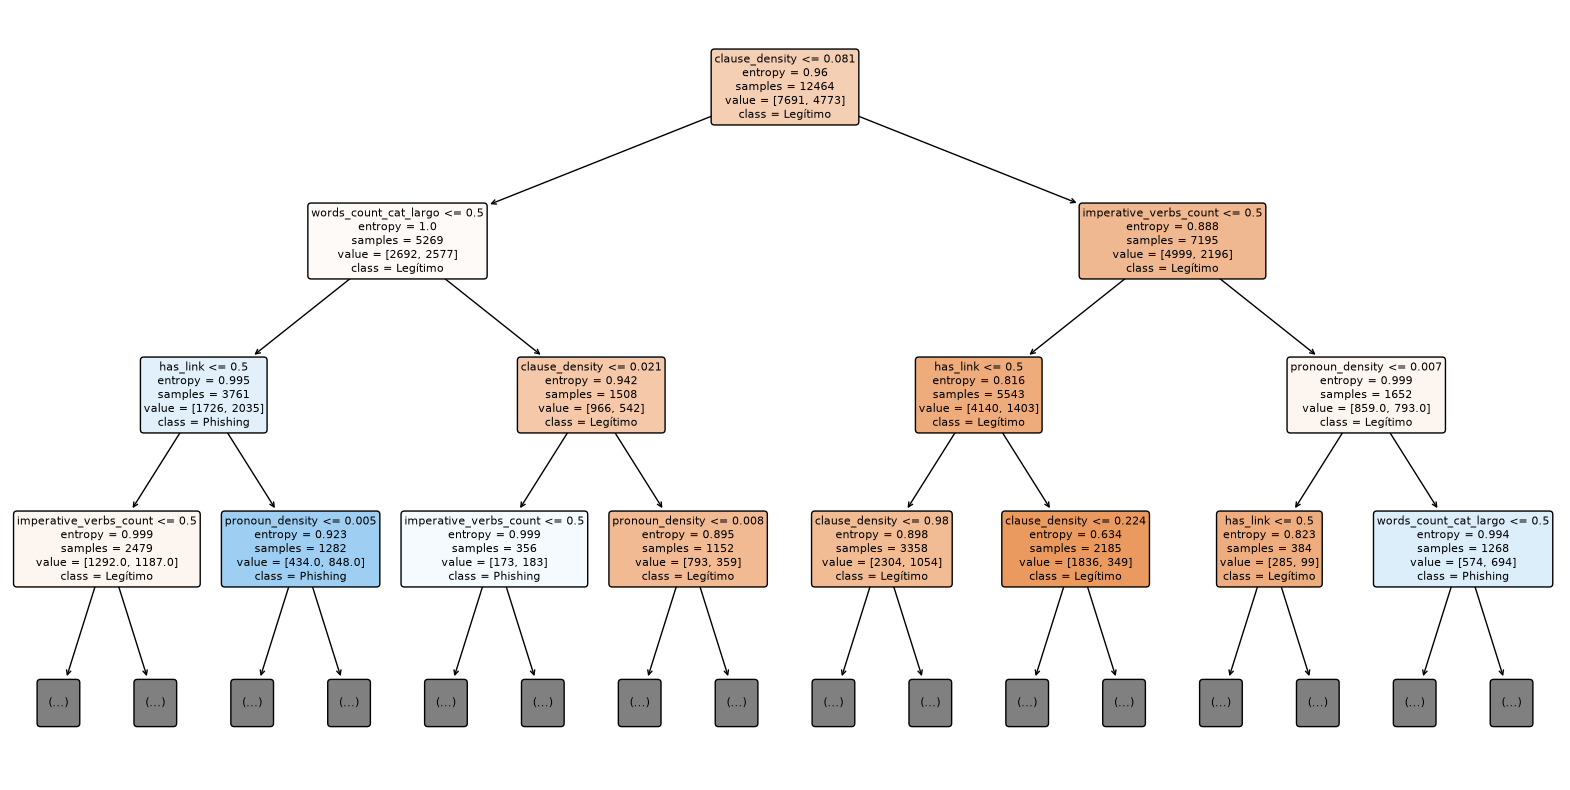

In [5]:
feature_names = X_train.columns

plt.figure(figsize=(20, 10))
plot_tree(classification, feature_names=feature_names, class_names=['Legítimo', 'Phishing'],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.show()

El árbol resultante tiene una **profundidad de 48** y **3351 hojas**, lo que indica un modelo extremadamente complejo que ha crecido sin restricciones, capturando probablemente ruido del conjunto de entrenamiento (sobreajuste).

## Evaluación del Modelo Base

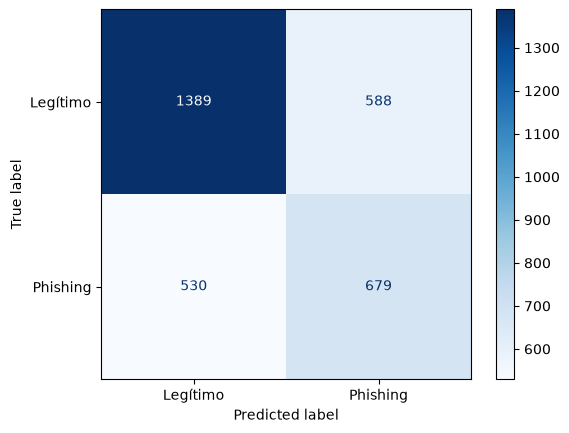

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [7]:
cm_tree = confusion_matrix(y_test, y_pred)
P = cm_tree[1, :].sum()
N = cm_tree[0, :].sum()
TP = cm_tree[1, 1]
TN = cm_tree[0, 0]

TPR_tree = TP / P
TNR_tree = TN / N
balanced_accuracy_tree = (TPR_tree + TNR_tree) / 2

precision_tree = precision_score(y_test, y_pred, zero_division=0)
recall_tree = recall_score(y_test, y_pred, zero_division=0)
f1_tree = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_tree:.4f}")
print(f"Precisión:               {precision_tree:.4f}")
print(f"Sensibilidad (Recall):   {TPR_tree:.4f}")
print(f"F1-score:                {f1_tree:.4f}")
print(f"Especificidad:           {TNR_tree:.4f}")
print(f"Recuperación (Recall):   {recall_tree:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.6321
Precisión:               0.5359
Sensibilidad (Recall):   0.5616
F1-score:                0.5485
Especificidad:           0.7026
Recuperación (Recall):   0.5616
Tiempo de entrenamiento: 0:00:00.191140
Tiempo de predicción:    0:00:00.002828


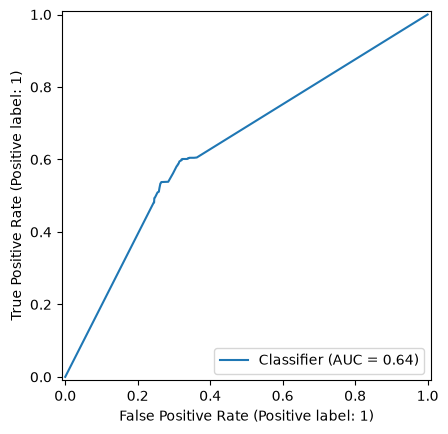

In [8]:
y_scores = classification.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Los resultados son pobres: una exactitud balanceada cercana al nivel de adivinación aleatoria, con una sensibilidad baja y una tasa significativa de falsos negativos. La curva ROC también es modesta, confirmando el bajo poder discriminativo del modelo sin restricciones, sobreajustado a los datos de entrenamiento.

## Análisis de Importancia de Características y Estructura del Árbol

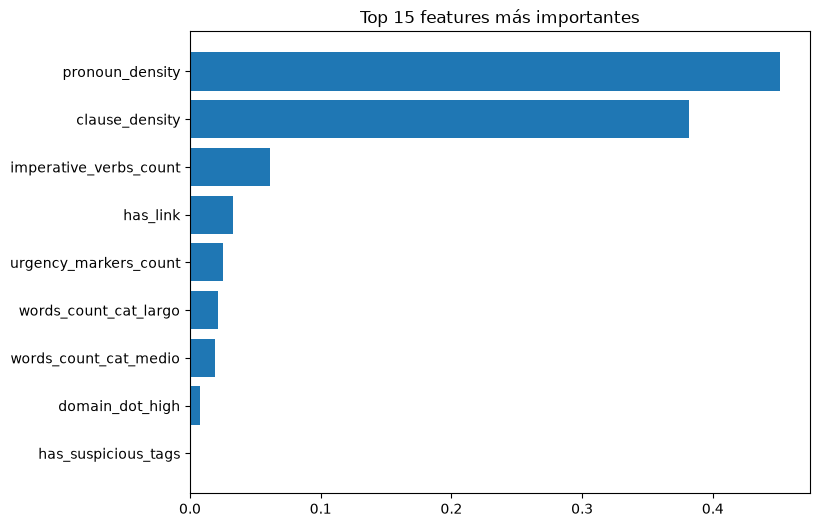

Profundidad del árbol: 48
Cantidad de hojas: 3351


In [9]:
importances = classification.feature_importances_
top_idx = np.argsort(importances)[-15:]
plt.figure(figsize=(8,6))
plt.barh([feature_names[i] for i in top_idx], importances[top_idx])
plt.title('Top 15 features más importantes')
plt.show()

print(f"Profundidad del árbol: {classification.get_depth()}")
print(f"Cantidad de hojas: {classification.get_n_leaves()}")

El modelo base sin restricciones genera una estructura profundamente compleja:
* **Profundidad máxima del árbol:** 48 niveles.
* **Cantidad total de hojas:** 3,351 nodos terminales.

* **Sobreajuste:** El árbol memorizó los datos de entrenamiento creando divisiones hiper-específicas para casi cada correo. Esto explica la marcada degradación del rendimiento en el conjunto de prueba (Exactitud balanceada: 0.63, F1-score: 0.5485).
* **Importancia de Atributos:** El ranking de importancia de características (*Gini/Entropy Importance*) confirma que las variables estilométricas y sintácticas aisladas guían las primeras divisiones del árbol, aunque sin la capacidad de separar ambas clases de forma robusta por sí solas.

## Optimización de parámetros

Se define una función objetivo para Optuna que maximiza el F1-score promedio en validación cruzada (3-fold). Los hiperparámetros explorados son:

* `criterion`: gini, entropy, log_loss
* `splitter`: best, random
* `max_depth`: rango [2, 32]
* `min_samples_split`: rango [2, 20]
* `min_samples_leaf`: rango [1, 20]

In [10]:
def objective(trial):
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    splitter = trial.suggest_categorical("splitter", ["best", "random"])
    max_depth = trial.suggest_int("max_depth", 2, 32)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    model = DecisionTreeClassifier(criterion=criterion, splitter=splitter,
                                        max_depth=max_depth, min_samples_split=min_samples_split,
                                        min_samples_leaf=min_samples_leaf, random_state=42)

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan **500 trials** con el podador `HyperbandPruner`.

In [11]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
start_train_time_opt = datetime.now()
study.optimize(objective, n_trials=500, callbacks=[champion_callback], n_jobs=-1)
end_train_time_opt = datetime.now()

train_duration_opt = end_train_time_opt - start_train_time_opt

Initial trial 5 achieved value: 0.5522883310043346
Trial 4 achieved value: 0.5659888283224509 with  2.4206% improvement
Trial 18 achieved value: 0.5664637768519922 with  0.0838% improvement
Trial 20 achieved value: 0.5759801309517049 with  1.6522% improvement


In [12]:
best_params = study.best_params
best_params

{'criterion': 'log_loss',
 'splitter': 'best',
 'max_depth': 16,
 'min_samples_split': 19,
 'min_samples_leaf': 14}

## Modelo Optimizado

Se re-entrena el árbol con los parámetros óptimos.

In [13]:
optimized_classification = DecisionTreeClassifier(**best_params, random_state=42)

start_train_opt = datetime.now()
optimized_classification.fit(X_train, y_train)
train_duration_opt = datetime.now() - start_train_opt

start_pred_opt = datetime.now()
y_pred = optimized_classification.predict(X_test)
predict_duration_opt = datetime.now() - start_pred_opt

## Comparativa de Métricas

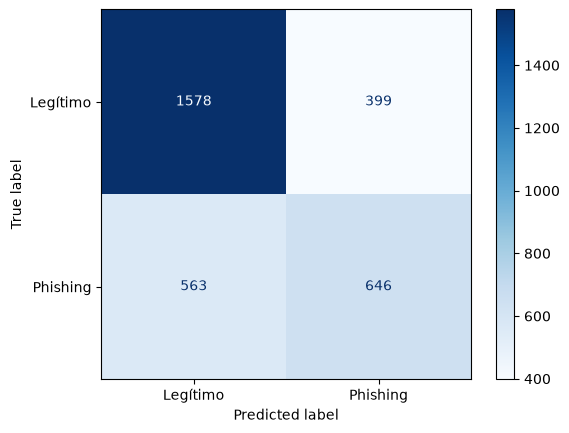

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [15]:
cm_optimized_tree = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_tree[1, :].sum()
N_opt = cm_optimized_tree[0, :].sum()
TP_opt = cm_optimized_tree[1, 1]
TN_opt = cm_optimized_tree[0, 0]

TPR_tree_opt = TP_opt / P_opt
TNR_tree_opt = TN_opt / N_opt
balanced_accuracy_tree_opt = (TPR_tree_opt + TNR_tree_opt) / 2

precision_tree_opt = precision_score(y_test, y_pred, zero_division=0)
recall_tree_opt = recall_score(y_test, y_pred, zero_division=0)
f1_tree_opt = f1_score(y_test, y_pred, zero_division=0)

print("                         Antes           Después")
print(f"Exactitud balanceada:    {balanced_accuracy_tree:.4f}          {balanced_accuracy_tree_opt:.4f}")
print(f"Precisión:               {precision_tree:.4f}          {precision_tree_opt:.4f}")
print(f"Sensibilidad (Recall):   {TPR_tree:.4f}          {TPR_tree_opt:.4f}")
print(f"F1-score:                {f1_tree:.4f}          {f1_tree_opt:.4f}")
print(f"Especificidad:           {TNR_tree:.4f}          {TNR_tree_opt:.4f}")
print(f"Recuperación (Recall):   {recall_tree:.4f}          {recall_tree_opt:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}  {train_duration_opt}")
print(f"Tiempo de predicción:    {predict_duration}  {predict_duration_opt}")

                         Antes           Después
Exactitud balanceada:    0.6321          0.6663
Precisión:               0.5359          0.6182
Sensibilidad (Recall):   0.5616          0.5343
F1-score:                0.5485          0.5732
Especificidad:           0.7026          0.7982
Recuperación (Recall):   0.5616          0.5343
Tiempo de entrenamiento: 0:00:00.191140  0:00:00.056823
Tiempo de predicción:    0:00:00.002828  0:00:00.002567


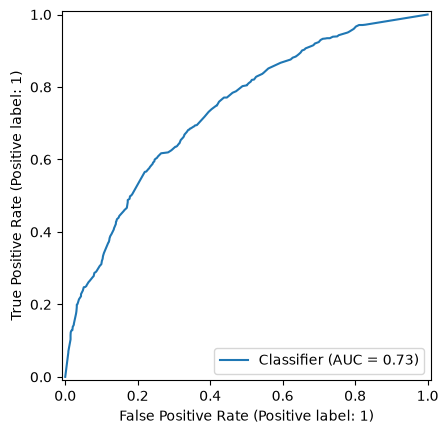

In [16]:
y_scores = optimized_classification.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

La optimización produce una leve mejora pero clara: la exactitud balanceada sube de 0.63 a 0.67, la precisión de 0.54 a 0.62, la especificidad de 0.70 a 0.80 y el F1-score de 0.55 a 0.57. Sin embargo, la sensibilidad disminuye ligeramente de 0.56 a 0.53. El tiempo de entrenamiento se reduce notablemente gracias a la restricción de profundidad (de 48 a 16 niveles).

## Análisis de Resultados y Conclusiones

La optimización de hiperparámetros mediante restricción de profundidad y control del tamaño de hojas aporta grandes mejoras en la capacidad de generalización del árbol de decisión:

* **Control del Sobreajuste:** La reducción de la profundidad máxima (de 48 a 16) y el establecimiento de límites de muestras por hoja (14) permitieron simplificar la estructura del árbol, incrementando la especificidad del **0.70** al **0.79** y la precisión del **0.53.59** a **0.61**.
*3.* **Limitaciones Teóricas de Árboles Individuales:** A pesar del podado, los árboles de decisión individuales entrenados únicamente con atributos tabulares muestran un techo en su capacidad predictiva en este problema (0.66 de exactitud balanceada). Esto confirma la necesidad de adoptar enfoques de ensambles (*Boosting*) o incluir representaciones vectoriales TF-IDF mediante clasificadores no lineales/lineales robustos.